# Tutorial 5: Querying ccRCC TLS Subtypes in NSCLC

We use a QueST model pretrained on NSCLC to ask whether the three TLS subtypes discovered in ccRCC (Tutorial 4) also appear in NSCLC tumours. We first pretrain the QueST model on NSCLC data (checkpoint at https://cloud.tsinghua.edu.cn/d/90a0bdca43ce4f8da5c0/) and then extract ccRCC TLS embeddings with it for niche querying.

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import sys
import logging
import warnings
import torch
import numpy as np
import scanpy as sc
import squidpy as sq
import torch.nn.functional as F
import matplotlib.pyplot as plt

/nfs/public/chenmo/anaconda3/envs/quest-test/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [ ]:
import sys, os
import quest.utils as utils

In [ ]:
warnings.filterwarnings('ignore')
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.WARNING)

## 1. Configure paths and TLS subtype groups

We list the three NSCLC slices and the ccRCC slices that carry TLS annotations. `TLS_GROUPS` records which TLS belong to which subtype — these are the three groups (A / B1 / B2) discovered in Tutorial 4.

In [ ]:
DEVICE = 'cuda:0'

ccrcc_data_path = '../data/ccRCC'
nsclc_data_path = '../data/NSCLC'
model_path = '../results/NSCLC/model/quest_model.pth'

ccrcc_sample_ids = [
    'ffpe_c_2',  'ffpe_c_3',    'ffpe_c_4',   'ffpe_c_7',   'ffpe_c_20',  'ffpe_c_34',
    'ffpe_c_36', 'ffpe_c_39',   'ffpe_c_45',  'ffpe_c_51',  'frozen_a_3', 'frozen_a_15',
    'frozen_b_1','frozen_b_18', 'frozen_c_57',
]
nsclc_sample_ids = ['nsclc_batch_1', 'nsclc_batch_2', 'nsclc_batch_3']

TLS_GROUPS = {
    'A':  [f'TLS_{i}' for i in [11, 12, 13, 17, 18, 21, 22]],
    'B1': [f'TLS_{i}' for i in [1, 2, 4, 10, 14, 15, 16, 23, 34]],
    'B2': [f'TLS_{i}' for i in [3, 5, 6, 7, 8, 9, 19, 20, 24, 25, 26, 27]],
}

## 2. Load the NSCLC-pretrained model

In [ ]:
nsclc_ref = sc.read_h5ad(f'{nsclc_data_path}/{nsclc_sample_ids[0]}.h5ad')
nsclc_genes = list(nsclc_ref.var_names)

model, model_param = utils.load_pretrained_model(
    model_path, in_dim=len(nsclc_genes),
    batch_num=len(nsclc_sample_ids), device=DEVICE,
)

## 3. Extract per-TLS embeddings on ccRCC slices

In [ ]:
ccrcc_adatas = [sc.read_h5ad(f'{ccrcc_data_path}/{sid}.h5ad') for sid in ccrcc_sample_ids]
tls_embeddings = utils.encode_subgraphs_with_genes(
    model, ccrcc_adatas, genes=nsclc_genes,
    group_key='tls_group', exclude_values=['NO_TLS'], device=DEVICE,
)
print(f'Extracted {len(tls_embeddings)} TLS embeddings')

Extracted 28 TLS embeddings


## 4. Score NSCLC niches against each TLS subtype

In [ ]:
nsclc_adata_list = [sc.read_h5ad(f'{nsclc_data_path}/{sid}.h5ad') for sid in nsclc_sample_ids]
utils.score_query_by_groups(
    model, model_param, nsclc_adata_list,
    query_embeddings=tls_embeddings, group_dict=TLS_GROUPS,
    prefix='score_', device=DEVICE,
)
for adata in nsclc_adata_list:
    print(f'{adata.uns.get("library_id", "")}: scored ({adata.n_obs} cells)')

computing 3-hop subgraph (nsclc_batch_3): 100%|██████████| 91691/91691 [00:54<00:00, 1676.20it/s]


nsclc_batch_1: scored (93206 cells)
nsclc_batch_2: scored (97487 cells)
nsclc_batch_3: scored (91691 cells)


## 5. Define type-wise queried regions

The continuous per-subtype scores are turned into discrete labels in two steps:

1. TLS filter: Compute `agg_max = max(score_A, score_B1, score_B2)` per spot, then keep the top 10% within each slice as TLS candidates (the queried region).
2. Type-wise queried region: On the TLS queried region, take `argmax(score_A, score_B1, score_B2)` and label each cell as `Type A` / `Type B1` / `Type B2`. Everything outside the queried region is labelled `'Else'`.

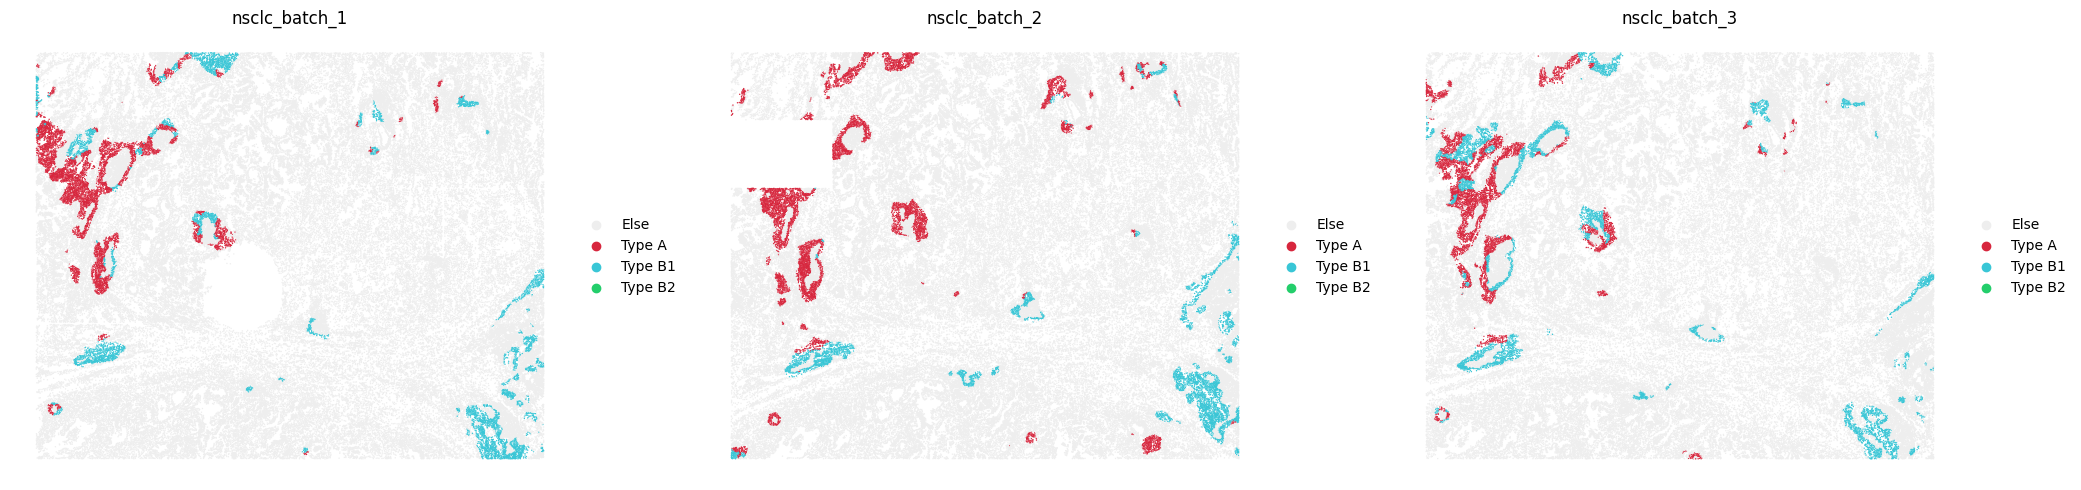

In [ ]:
for adata in nsclc_adata_list:
    utils.compute_queried_tls_region_labels(adata, score_cols=['score_A', 'score_B1', 'score_B2'])

utils.plot_queried_tls_region_spatial(nsclc_adata_list)